In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV
from surprise import accuracy
from sklearn.metrics import precision_recall_curve, auc

In [12]:
# Load dataset from CSV file 
csv_filename = "dataset/groceries_data.csv"  
df = pd.read_csv(csv_filename)

In [13]:
# Ensure Ratings are Numeric and Drop NaNs
df["Ratings"] = pd.to_numeric(df["Ratings"], errors="coerce")
df = df.dropna(subset=["Ratings"])

In [14]:
df.head()

,Person,Item,Ratings
0,1,citrus fruit,9.0
1,1,semi-finished bread,7.0
2,1,margarine,8.0
3,1,ready soups,7.0
4,2,tropical fruit,9.0


In [15]:
# Remove Users with Less than 5 Ratings (Data Sparsity Fix)
min_ratings = 5
user_counts = df["Person"].value_counts()
df = df[df["Person"].isin(user_counts[user_counts >= min_ratings].index)]

In [16]:
# Print Dataset Info
print("Unique Users:", df["Person"].nunique())
print("Unique Items:", df["Item"].nunique())
print("Total Records:", len(df))

Unique Users: 3724
Unique Items: 162
Total Records: 29905


In [18]:
df.to_csv("dataset/filtered.csv", index=False)

In [19]:
# Define Reader & Load Data
reader = Reader(rating_scale=(1, 9))
data = Dataset.load_from_df(df[["Person", "Item", "Ratings"]], reader)

In [20]:
# Perform GridSearch for Hyperparameter Tuning
param_grid = {
    'n_factors': [20, 50, 100],  
    'reg_all': [0.02, 0.05, 0.1]  
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs.fit(data)

In [21]:
# Best Hyperparameters
best_params = gs.best_params['rmse']
print(f"Best SVD Parameters: {best_params}")

Best SVD Parameters: {'n_factors': 20, 'reg_all': 0.02}


In [22]:
# Initialize Best Model
model = SVD(n_factors=best_params['n_factors'], reg_all=best_params['reg_all'])

In [23]:
# Perform Cross-Validation (5-Fold)
cv_results = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4173  0.4568  0.3896  0.4063  0.4065  0.4153  0.0226  
MAE (testset)     0.1914  0.1918  0.1907  0.1985  0.1936  0.1932  0.0028  
Fit time          0.09    0.10    0.11    0.10    0.11    0.10    0.01    
Test time         0.02    0.02    0.02    0.02    0.02    0.02    0.00    


In [24]:
# Extract Mean RMSE & MAE
mean_rmse_cv = np.mean(cv_results['test_rmse'])
mean_mae_cv = np.mean(cv_results['test_mae'])

print(f"Mean RMSE (5-Fold Cross Validation): {mean_rmse_cv:.4f}")
print(f"Mean MAE (5-Fold Cross Validation): {mean_mae_cv:.4f}")

Mean RMSE (5-Fold Cross Validation): 0.4153
Mean MAE (5-Fold Cross Validation): 0.1932


In [25]:
# Split Data into Train & Test Sets Properly
trainset, testset = train_test_split(data, test_size=0.2)

In [26]:
# Train the Model
model.fit(trainset)

In [27]:
# Save the Trained Model
model_filename = "model/svd_grocery_recommendation.pkl"
with open(model_filename, "wb") as file:
    pickle.dump(model, file)
print(f"Model saved as {model_filename}")

Model saved as model/svd_grocery_recommendation.pkl


In [28]:
# **Load the Trained Model**
with open(model_filename, "rb") as file:
    loaded_model = pickle.load(file)
print("Loaded saved model successfully.")

Loaded saved model successfully.


In [29]:
# Evaluate on Test Set
test_predictions = loaded_model.test(testset)
rmse_test = accuracy.rmse(test_predictions)
mae_test = accuracy.mae(test_predictions)

RMSE: 0.4426
MAE:  0.1990


In [30]:
# Generate Recommendations for a User (Person 6)
person_id = 6
all_items = df["Item"].unique()
user_rated_items = df[df["Person"] == person_id]["Item"].values

In [31]:
# Predict ratings for all items not yet rated
predicted_ratings = [(item, loaded_model.predict(person_id, item).est) for item in all_items if item not in user_rated_items]

In [32]:
# Sort by highest predicted ratings
top_recommendations = sorted(predicted_ratings, key=lambda x: x[1], reverse=True)[:5]

In [33]:
# Convert to DataFrame for display
recommendations_df = pd.DataFrame(top_recommendations, columns=["Item", "Predicted Rating"])

In [34]:
# Display Recommendations
recommendations_df

,Item,Predicted Rating
0,herbs,8.777035
1,root vegetables,8.758568
2,other vegetables,8.749492
3,citrus fruit,8.747499
4,packaged fruit/vegetables,8.742590


In [35]:
# Precision-Recall Curve Calculation
y_true = []
y_scores = []

for uid, iid, true_r, est, _ in test_predictions:
    y_true.append(true_r)
    y_scores.append(est)

In [36]:
# Convert to NumPy Arrays
y_true = np.array(y_true)
y_scores = np.array(y_scores)

In [38]:
# Define a threshold for relevant vs non-relevant items
threshold = 7  # Consider ratings >= 7 as relevant (1), others as non-relevant (0)

# Convert y_true into binary format (1 for relevant, 0 for not relevant)
y_true_binary = np.where(y_true >= threshold, 1, 0)

# Compute Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)

In [39]:
# Compute Area Under Curve (AUC)
pr_auc = auc(recall, precision)

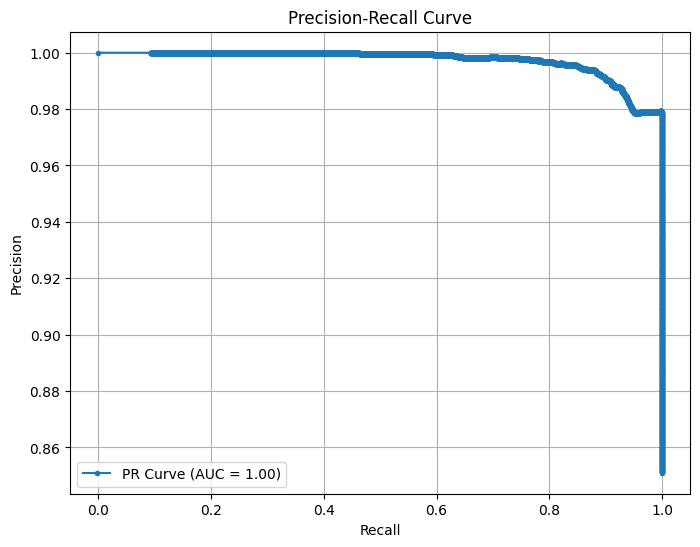

In [40]:
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# **Final Accuracy Metrics**
print("\nFinal Model Evaluation:")
print(f"RMSE (Test Set): {rmse_test:.4f}")
print(f"MAE (Test Set): {mae_test:.4f}")


Final Model Evaluation:
RMSE (Test Set): 0.4426
MAE (Test Set): 0.1990


In [41]:
# Print Precision-Recall AUC
print(f"Precision-Recall AUC: {pr_auc:.4f}")

Precision-Recall AUC: 0.9973
